# **1. Perkenalan Dataset**


Untuk sumber dataset saya mendapatkannya dari Kaggle pada link berikut :
https://www.kaggle.com/datasets/yasserh/titanic-dataset

yang dimana disini berisi data terkait dengan penumpang kapal titanic yang berkemungkinan selamat dan yang tidak berdasarkana pada karakteristik penumpang mulai dari gender, age, class social, dan lain lain.

# **2. Import Library**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv('../data/Titanic-Dataset_raw.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **4. Exploratory Data Analysis (EDA)**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print(df.duplicated().sum())

0


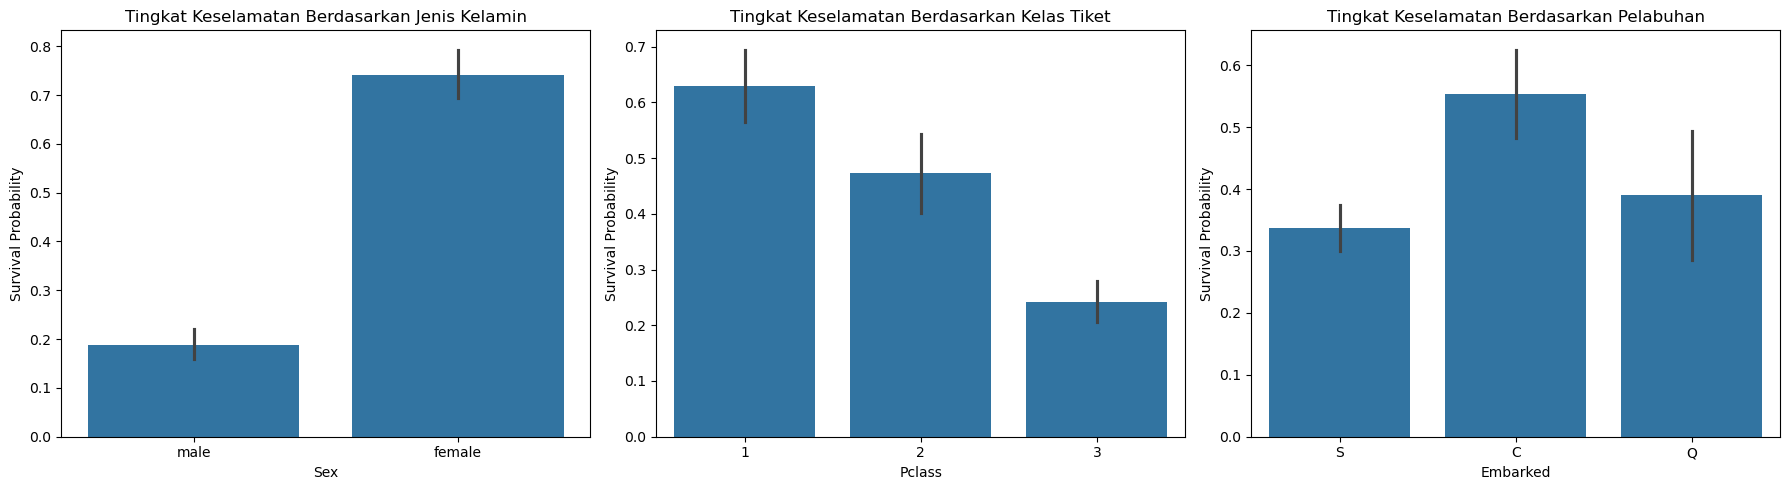

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0])
axes[0].set_title('Tingkat Keselamatan Berdasarkan Jenis Kelamin')
axes[0].set_ylabel('Survival Probability')

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1])
axes[1].set_title('Tingkat Keselamatan Berdasarkan Kelas Tiket')
axes[1].set_ylabel('Survival Probability')

sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[2])
axes[2].set_title('Tingkat Keselamatan Berdasarkan Pelabuhan')
axes[2].set_ylabel('Survival Probability')

plt.tight_layout()
plt.show()

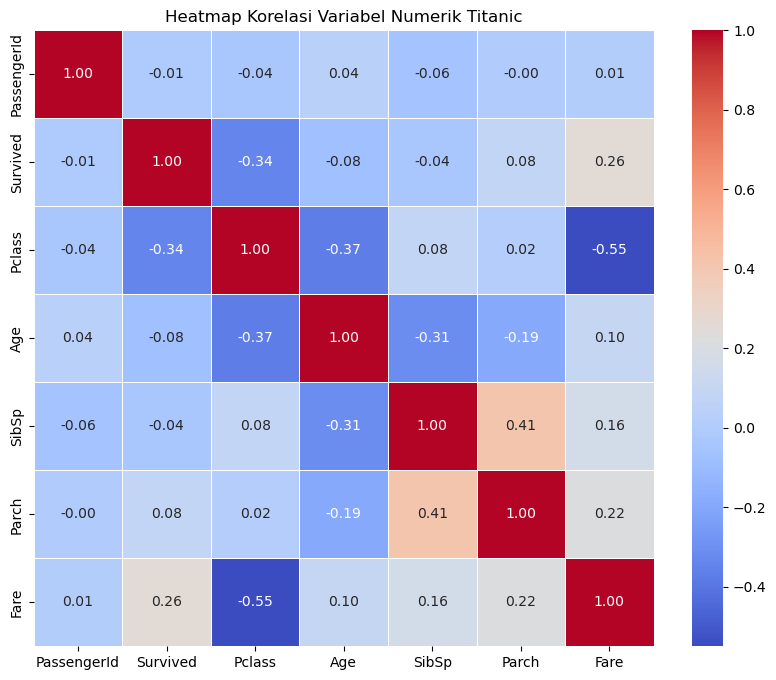

In [8]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Variabel Numerik Titanic")
plt.show()

In [9]:
numeric_df.skew()

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64

Dari data tersebut diketahui :
- Ada missing value di Age, Embarked, dan Cabin
- Penumpang Perempuan dan Pclass 1 punya peluang selamat lebih tinggi
- Fitur numerik semua aman gak ada multikolinearitas
- Fitur Fare sangat right skew

# **5. Data Preprocessing**

In [10]:
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [11]:
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

In [12]:
numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)